# Chapter 3: The Weather That Could Be Computed
Lorenz dynamics are a small educational example of sensitivity to initial
conditions, not an operational weather forecast. We also extract a seasonal
component from synthetic monthly data and inspect its frequency spectrum.

In [1]:
from pathlib import Path
import sys
project=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'companion/src').exists())
sys.path.insert(0,str(project/'companion/src'))
from forecasting_companion.common import *
from scipy.integrate import solve_ivp
from statsmodels.tsa.seasonal import STL
rng=begin(3)

## Deterministic equations, uncertain initial state

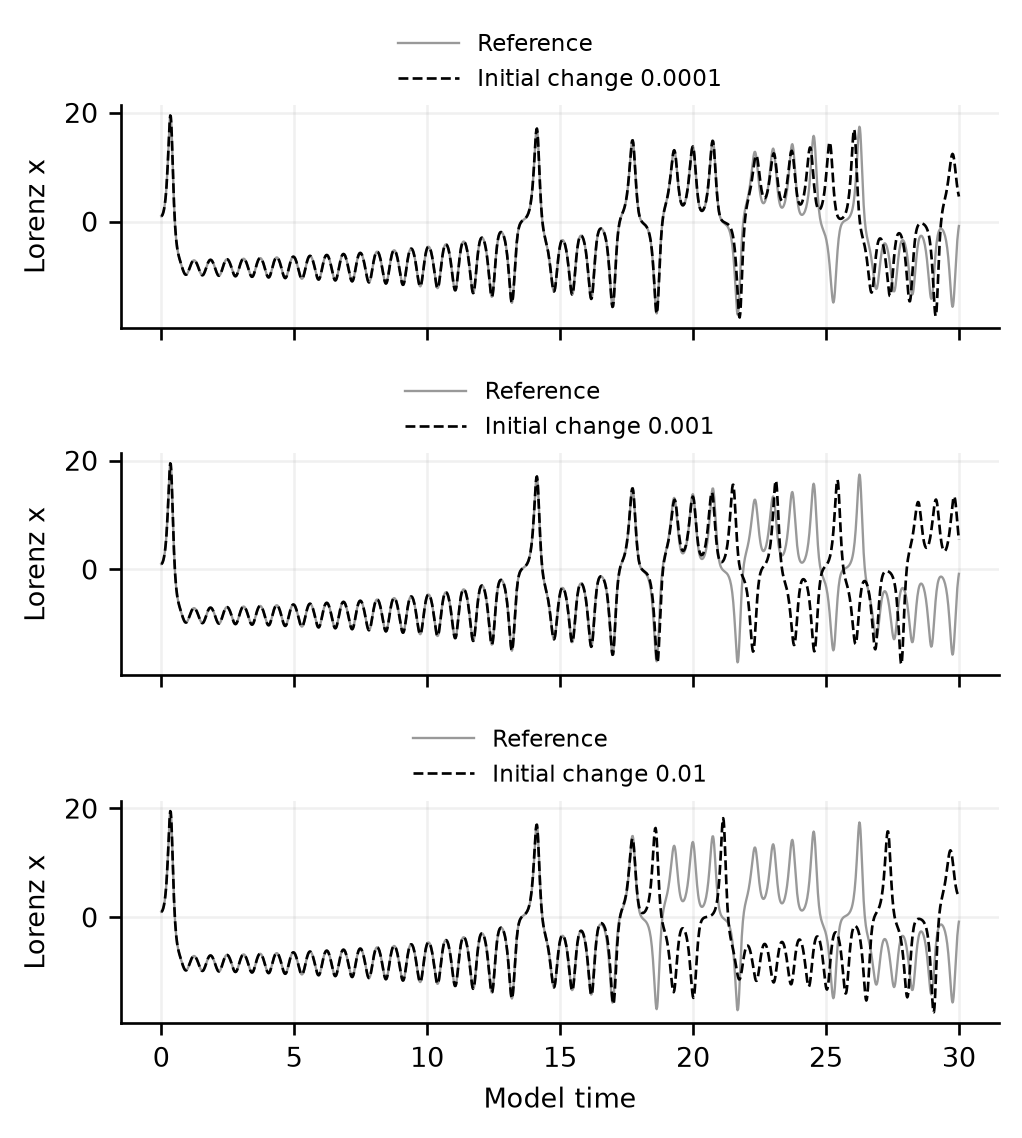

In [2]:
def lorenz(t,s):
    x,y,z=s
    return [10*(y-x),x*(28-z)-y,x*y-8*z/3]
t=np.linspace(0,30,1500)
paths=np.array([solve_ivp(lorenz,[0,30],[1+e,1,1],t_eval=t,rtol=1e-8,atol=1e-10).y[0] for e in [0,.0001,.001,.01]])
fig,axes=plt.subplots(3,1,figsize=(4.3,4.8),sharex=True,sharey=True)
for ax,e,path in zip(axes,[.0001,.001,.01],paths[1:]):
    ax.plot(t,paths[0],color='.6',lw=.7,label='Reference')
    ax.plot(t,path,color='black',ls='--',lw=.8,label=f'Initial change {e}')
    ax.set_ylabel('Lorenz x'); ax.legend()
axes[-1].set_xlabel('Model time')
save(3,1,'Small initial differences become different futures','Each panel compares the same reference with one perturbed initial x on common axes. Numerical Lorenz trajectories; model time is dimensionless, not forecast days.','## II. The ENIAC Run and the Modern Era',fig)

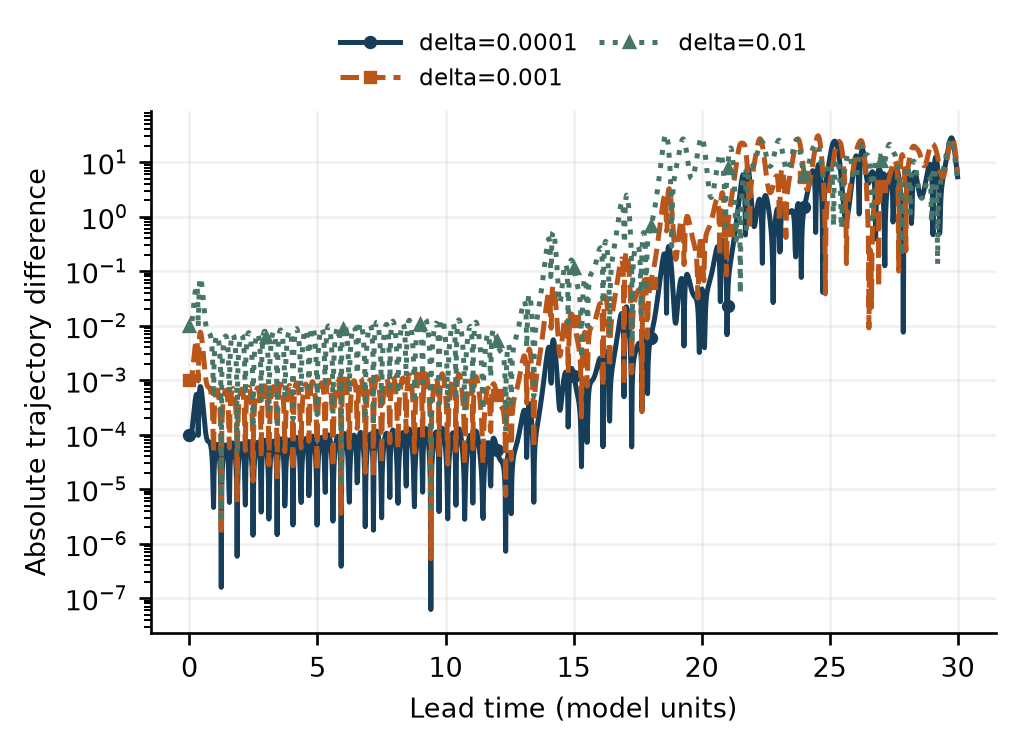

In [3]:
plt.figure()
for e,path in zip([.0001,.001,.01],paths[1:]): plt.semilogy(t,np.maximum(abs(path-paths[0]),1e-9),label=f'delta={e}')
plt.xlabel('Lead time (model units)'); plt.ylabel('Absolute trajectory difference'); plt.legend(fontsize=7)
save(3,2,'Uncertainty grows with the forecast horizon','Absolute divergence from the reference trajectory. Growth is irregular and bounded by the dynamical system; it is not indefinite exponential growth.','## II. The ENIAC Run and the Modern Era')

## Separate trend, seasonality and remainder
Decomposition uses the full example for description. Forecasting would refit
it at each origin; full-series components must not leak into validation features.

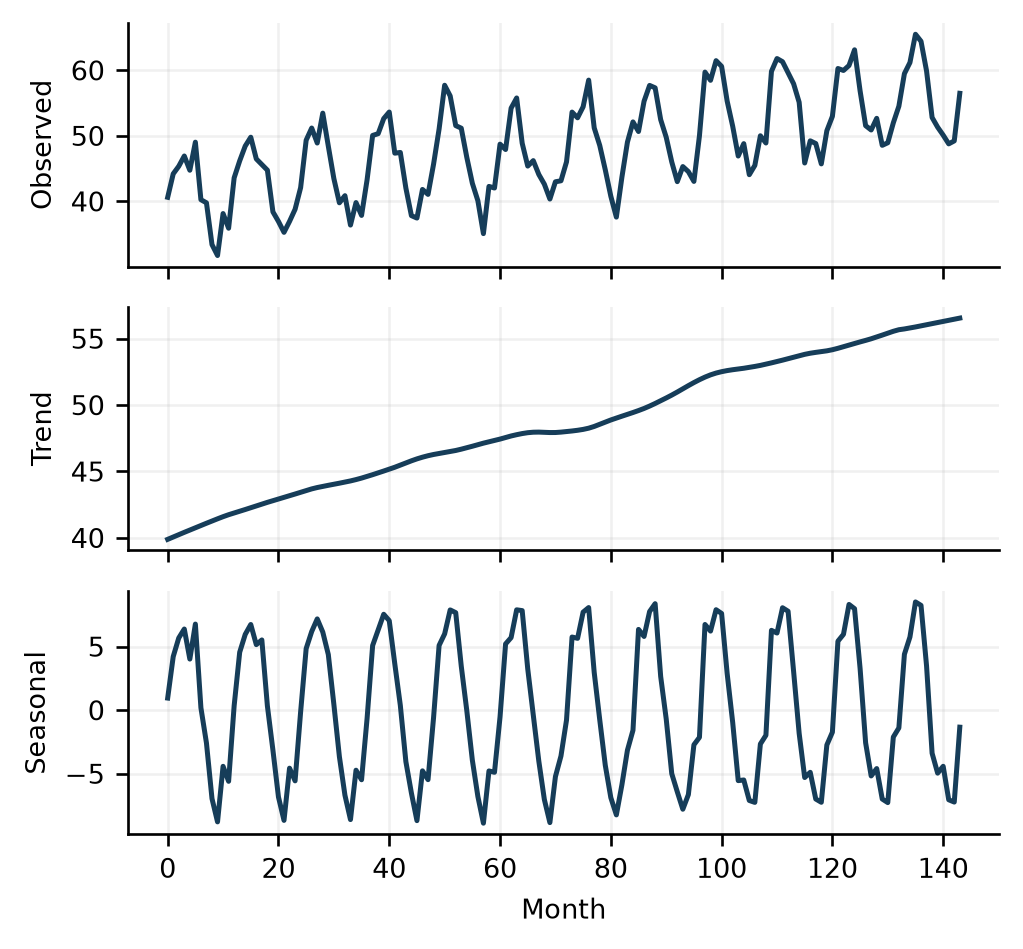

Dominant nonzero frequency: 0.08333333333333333


In [4]:
y=seasonal_series(rng); fit=STL(y,period=12,robust=True).fit()
fig,axes=plt.subplots(3,1,figsize=(4.3,4),sharex=True)
for ax,values,label in zip(axes,[y,fit.trend,fit.seasonal],['Observed','Trend','Seasonal']): ax.plot(values); ax.set_ylabel(label)
axes[-1].set_xlabel('Month')
save(3,3,'Structure beneath a noisy series','STL decomposition of synthetic monthly observations. Trend and seasonality are estimates, not independently observed causes.','## IV. Time Series Structure as Methodology',fig)
freq=np.fft.rfftfreq(len(y)); power=abs(np.fft.rfft(y-fit.trend))**2
print('Dominant nonzero frequency:',freq[1:][np.argmax(power[1:])])
assert np.allclose(y,fit.trend+fit.seasonal+fit.resid)

## Limits and exercise
Try a different integration tolerance and initial perturbation. Try two seasonal
periods and compare STL with MSTL. X-13 and regime-switching models are extensions
requiring additional assumptions; weather-scale assimilation is outside this toy.
Wold's moving-average component contains predictable past innovations; only
innovations not yet observed are unpredictable under its assumptions.

<!-- APPLIED-WORKSHOP-START -->
## Guided application workshop
The sections below come from the chapter skill: the mechanism, the arithmetic, how to adapt the lesson to your data, exercises with worked solutions, and the exact contract of the applied tool.

## Input contract and format example
CSV timestamp,target on a regular unique calendar; metadata frequency, season,units and cutoff. For a dynamics experiment separately specify the equations, initial states and integration tolerance; those are not columns in the business-series CSV.

Minimal **format illustration**, not sufficient training data:

```csv
timestamp,target
2024-01-01,100
2024-02-01,110
```

## Explain the mechanism

Deterministic equations can be sensitive to uncertain starting conditions. Business decomposition asks a related but distinct question: what slowly changing and repeating patterns summarize observations? Neither computation removes uncertainty about whether those patterns persist.

## Work through the arithmetic

If a monthly observation is 120, estimated trend is 100 and seasonal component is 15, the remainder is 5. A spectral frequency 1/12 cycles per month corresponds to a 12-month period. Frequency is reciprocal period, not the number of months itself.

## Adapt the lesson to reader data

Replace seasonal_series in the STL block with the regular user series and update period. Leave Lorenz simulation separate from that business analysis. If using decomposition features in a model, move the STL fit inside the historical-origin loop rather than decomposing once before splitting.

For this chapter, settle these questions before fitting: What interval is sampled? Which seasonal periods are physically or commercially plausible? Is the goal descriptive decomposition or future forecasting? Are current state estimates uncertain?

## Interpret the actual lesson outputs

The Lorenz panels compare initial perturbations against the same reference with shared axes. Their horizontal units are dimensionless. The STL reconstruction assertion checks arithmetic, not forecast quality; the printed dominant frequency describes the controlled series.

The current applied adapter adds a separately inspectable numerical result:

- `results.csv`: `timestamp,observed,trend,seasonal,remainder`.
- `summary.json`: `max_trend_revision` plus method, interpretation, assumptions, not_done and status.

STL is descriptive. At least three seasonal cycles are required. The adapter refits an earlier vintage and reports the maximum historical trend revision; it does not issue a weather or business forecast.

## Decide what the evidence supports

A spectral peak may reflect trend, aliasing or limited sample length; detrend and inspect calendar plausibility. Estimated components are not observed causes. Lorenz trajectories do not specify a calibrated business prediction interval.

With irregular sampling, first decide whether calendar aggregation is defensible; do not run a regular-grid FFT uncritically. With too few cycles, use plots and a simple baseline and mark seasonal decomposition provisional.

The applied deliverable must make these items inspectable: `results.csv` columns: `timestamp,observed,trend,seasonal,remainder`; `summary.json` keys: `max_trend_revision` plus method, interpretation, assumptions, not_done and status. Return the calendar audit, chosen period and rationale, decomposition table, reconstruction error, and any origin-safe baseline comparison. For dynamics report initial-state and numerical-tolerance assumptions separately.

## Three exercises with worked solutions

### Exercise 1

Frequency is .25 cycles per quarter. What is the period?

**Worked solution.** Four quarters, because 1/.25=4.

### Exercise 2

Can a smoother using next December’s value construct a forecast for this June?

**Worked solution.** No. Full-sample decomposition leaks future observations; refit at June’s cutoff.

### Exercise 3

A changed integration tolerance produces nearly identical short trajectories. Has initial uncertainty vanished?

**Worked solution.** No. That checks numerical stability locally; uncertainty in the true starting state remains.

## Business-reader application

Use this request with the skill:

> Use chapter 3 to audit the seasonality of demand.csv and explain which components are retrospective and which can safely inform future forecasts.

## Observed-data transfer exercise

A bundled [observed series](../data/observed/monthly-temperature.csv) and [matching config](../configs/ch03-observed.json) provide a second application after the controlled fixture. Read the [data registry](../data/registry.json) for provenance and transformations. These are historical snapshots, not archived real-time release vintages.

```bash
companion/.venv/bin/python companion/scripts/run.py apply --chapter 3 \
  --input companion/data/observed/monthly-temperature.csv \
  --config companion/configs/ch03-observed.json \
  --output companion/applied-runs/ch03-observed-reader
```

Inspect max_trend_revision and explain why full-history decomposition cannot supply origin-known features. Record the actual result of your run. Do not import the controlled example’s winner or interpret a successful numerical execution as evidence of operational accuracy.

Shared rules for data replacement, provenance, output folders and reading `status`: [conventions.md](../../forecasting-skills/all-chapters-forecasting/references/conventions.md).

## Apply this chapter to your own data

The two paths below are the only things to change: point `INPUT_PATH` at a file with the
columns in the input contract above and `CONFIG_PATH` at a copy of the shipped configuration
with your `source` and `units`. The call is the same tested function behind `run.py apply`.
The printed digest shows what ran, its status, the interpretation, the assumptions and the
`not_done` list; the full summary is saved beside the table. A validation error is a reason to
inspect the data, not to fill gaps with invented observations. Shared rules for provenance,
output folders and reading `status` are in the Complete Forecasting Skill's conventions reference.

In [5]:
from forecasting_companion.applied.methods import analyze as analyze_chapter
from forecasting_companion.applied.core import clean_json, summarize, preview
import pandas as pd
import json, os
project_path = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'companion/src').exists())
INPUT_PATH = project_path / 'companion/data/examples/ch03.csv'      # replace with your file
CONFIG_PATH = project_path / 'companion/configs/ch03.json'            # replace with your configuration
workshop_config = json.loads(CONFIG_PATH.read_text())
workshop_input = pd.read_csv(INPUT_PATH)
workshop_table, workshop_summary = analyze_chapter(3, workshop_input, workshop_config)
print(summarize(workshop_summary, workshop_table))
print()
print(preview(workshop_table))
workshop_output = Path(os.environ.get('FORECAST_OUTPUT', project_path / 'companion')) / 'results'
workshop_output.mkdir(parents=True, exist_ok=True)
workshop_table.to_csv(workshop_output/'ch03-workshop-results.csv', index=False)
_ = (workshop_output/'ch03-workshop-summary.json').write_text(json.dumps(clean_json(workshop_summary), indent=2)+'\n')

Method: Descriptive STL decomposition with a vintage comparison
Status: passed

Interpretation: STL with period 12 on 144 observations. Refitting without the last 12 points moved the trend by up to 0.8875: full-series components describe the past, and their revision after adding observations shows why they cannot be used as origin-known backtest features.

Assumptions:
  - The seasonal period is the declared season
  - Robust STL weights limit the influence of outliers
Not done:
  - No forecast: decomposition is descriptive (chapter 4 or 12 forecast the series)
  - No test of chaotic sensitivity beyond the vintage comparison

Evidence:
  max_trend_revision: 0.8875

Table: 144 rows, columns ['timestamp', 'observed', 'trend', 'seasonal', 'remainder']

 timestamp  observed  trend  seasonal  remainder
2010-01-01    41.289 41.720     0.127     -0.558
2010-02-01    41.754 41.629     8.470     -8.345
2010-03-01    49.552 41.537     7.518      0.498
2010-04-01    48.943 41.446     7.314      0

## The same workflow on observed data

A second run on a bundled public-domain series documented in `data/registry.json` (a revised
historical snapshot, not an archived real-time vintage). The earlier time cuts prevent fitting
on held-out outcomes; they do not undo revisions made before the snapshot was published.
Compare this digest with the controlled case above: a method need not win to be useful, and
the winner on synthetic data has no claim on observed data.

In [6]:
observed_input = pd.read_csv(project_path/'companion/data/observed/monthly-temperature.csv')
observed_config = json.loads((project_path/'companion/configs/ch03-observed.json').read_text())
observed_table, observed_summary = analyze_chapter(3, observed_input, observed_config)
print('Observed-data source:', observed_config['source'])
print(summarize(observed_summary, observed_table))
print()
print(preview(observed_table))
observed_table.to_csv(workshop_output/'ch03-observed-results.csv', index=False)
_ = (workshop_output/'ch03-observed-summary.json').write_text(json.dumps(clean_json(observed_summary), indent=2)+'\n')

Observed-data source: Public-domain statsmodels El Niño observations, 1950–2010; historical revised snapshot
Method: Descriptive STL decomposition with a vintage comparison
Status: passed

Interpretation: STL with period 12 on 732 observations. Refitting without the last 12 points moved the trend by up to 0.5907: full-series components describe the past, and their revision after adding observations shows why they cannot be used as origin-known backtest features.

Assumptions:
  - The seasonal period is the declared season
  - Robust STL weights limit the influence of outliers
Not done:
  - No forecast: decomposition is descriptive (chapter 4 or 12 forecast the series)
  - No test of chaotic sensitivity beyond the vintage comparison

Evidence:
  max_trend_revision: 0.5907

Table: 732 rows, columns ['timestamp', 'observed', 'trend', 'seasonal', 'remainder']

 timestamp  observed  trend  seasonal  remainder
1950-01-01     23.11 21.464     1.635      0.010
1950-02-01     24.20 21.551     2